In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [2]:
# Reload clean data
df = pd.read_csv('data/netflix_shows_clean.csv')
df['is_canceled'] = (df['status'] == 'Canceled').astype(int)

In [3]:
print(f"Shape: {df.shape}")
print(f"Cancellation rate: {df['is_canceled'].mean():.1%}")

Shape: (1485, 30)
Cancellation rate: 14.4%


In [4]:
# Drop redundant and non-predictive columns
drop_cols = ['id', 'name', 'status', 'days_since_last_episode',
             'last_air_date', 'first_air_date', 'keywords',
             'imdb_id', 'created_by', 'homepage', 'is_canceled',
             'rating_category', 'origin_country']



In [5]:
# Encode the top 5 languages and set everything else is 'other'
top_languages = ['en', 'ja', 'ko', 'es', 'hi']
df['language_encoded'] = df['original_language'].apply(
    lambda x: x if x in top_languages else 'other'
)

In [6]:
# Set one column per genre
genre_list = ['Drama', 'Comedy', 'Crime', 'Documentary', 'Animation',
              'Reality', 'Action & Adventure', 'Sci-Fi & Fantasy',
              'Mystery', 'Kids', 'Family']
for genre in genre_list:
    col = f"genre_{genre.lower().replace(' ', '_').replace('&', 'and')}"
    df[col] = df['genres'].fillna('').str.contains(genre).astype(int)

In [7]:
# Create binary columns for each unique language and type
language_dummies = pd.get_dummies(df['language_encoded'], prefix='lang')
type_dummies = pd.get_dummies(df['type'], prefix='type')

In [8]:
# Define numeric + binary features
numeric_features = ['popularity', 'num_seasons', 'num_episodes',
                    'weighted_rating', 'vote_count',
                    'years_since_premiere', 'genre_count']
flag_features = ['is_recent', 'is_popular']
genre_features = [f"genre_{g.lower().replace(' ', '_').replace('&', 'and')}" for g in genre_list]

In [9]:
# Assemble X and y
X = pd.concat([
    df[numeric_features + flag_features],
    language_dummies,
    type_dummies,
    df[genre_features]
], axis=1)

y = df['is_canceled']

print(f"Feature matrix: {X.shape}")
print(f"\nFeatures:\n{X.columns.tolist()}")

Feature matrix: (1485, 31)

Features:
['popularity', 'num_seasons', 'num_episodes', 'weighted_rating', 'vote_count', 'years_since_premiere', 'genre_count', 'is_recent', 'is_popular', 'lang_en', 'lang_es', 'lang_hi', 'lang_ja', 'lang_ko', 'lang_other', 'type_Documentary', 'type_Miniseries', 'type_Reality', 'type_Scripted', 'type_Talk Show', 'genre_drama', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_animation', 'genre_reality', 'genre_action_and_adventure', 'genre_sci-fi_and_fantasy', 'genre_mystery', 'genre_kids', 'genre_family']


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
# Split data into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# Set the same scaling parameters learned from the training set to the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
print(f"Train: {X_train.shape[0]} rows ({y_train.mean():.1%} canceled)")
print(f"Test:  {X_test.shape[0]} rows ({y_test.mean():.1%} canceled)")

Train: 1188 rows (14.4% canceled)
Test:  297 rows (14.5% canceled)


### Logistic Regression Model

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [15]:
# Train the model to find the features that best separate canceled from non-canceled shows
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [16]:
# Return predictions and probabilities for each show in test set
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [17]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr, target_names=['Not Canceled', 'Canceled']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

Not Canceled       0.96      0.77      0.85       254
    Canceled       0.37      0.81      0.51        43

    accuracy                           0.77       297
   macro avg       0.67      0.79      0.68       297
weighted avg       0.88      0.77      0.80       297

ROC-AUC: 0.847


### XGBoost Model

In [18]:
import xgboost as xgb
from xgboost import XGBClassifier

In [19]:
# Calculate the class imbalance ratio from the training data
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

scale_pos_weight: 5.95


In [20]:
# Create and train the model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [21]:
# Return predictions and probabilities for each show
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [22]:
print("\nXGBOOST")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Canceled', 'Canceled']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.3f}")


XGBOOST
              precision    recall  f1-score   support

Not Canceled       0.94      0.90      0.92       254
    Canceled       0.53      0.65      0.58        43

    accuracy                           0.87       297
   macro avg       0.73      0.78      0.75       297
weighted avg       0.88      0.87      0.87       297

ROC-AUC: 0.871


#### Champion model selected: XGBoost
##### Reasons: higher ROC-AUC (0.871 vs 0.847), better F1 on canceled class (0.58 vs 0.51), native SHAP support, better probability calibration for segmentation

In [23]:
champion = xgb
champion_probs = y_prob_xgb

print("Champion: XGBoost")
print(f"ROC-AUC: {roc_auc_score(y_test, champion_probs):.3f}")

Champion: XGBoost
ROC-AUC: 0.871


#### SHAP Analysis

In [24]:
import shap

explainer = shap.TreeExplainer(champion)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"X_test shape: {X_test.shape}")

SHAP values shape: (297, 31)
X_test shape: (297, 31)


#### SHAP Summary Plot

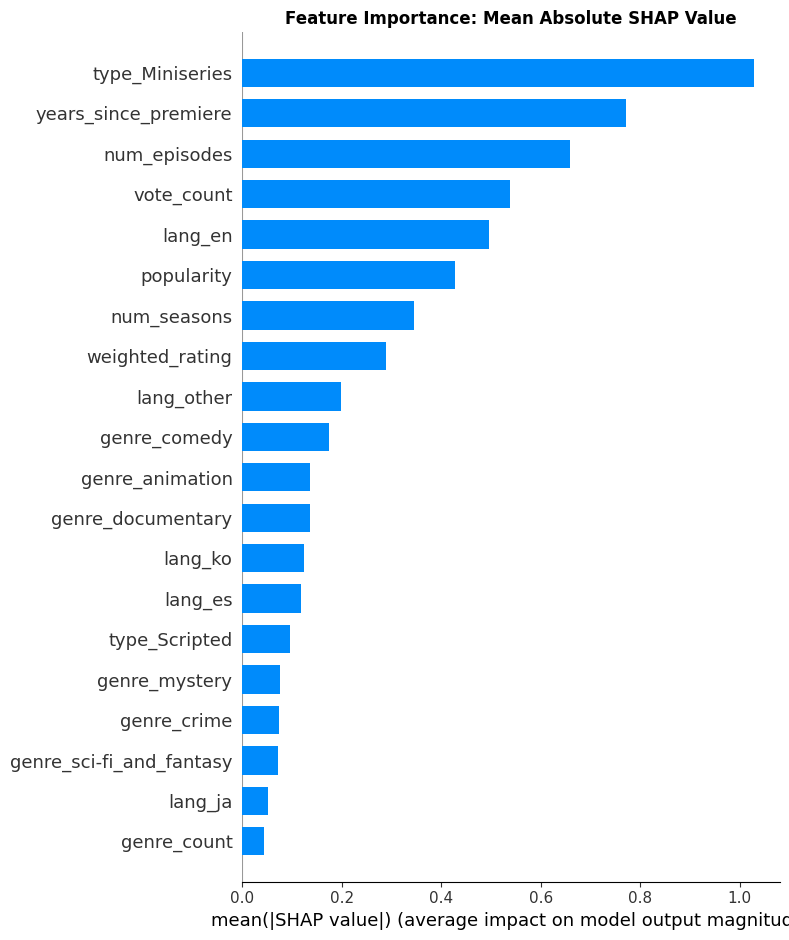

In [25]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Feature Importance: Mean Absolute SHAP Value', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/09_shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()

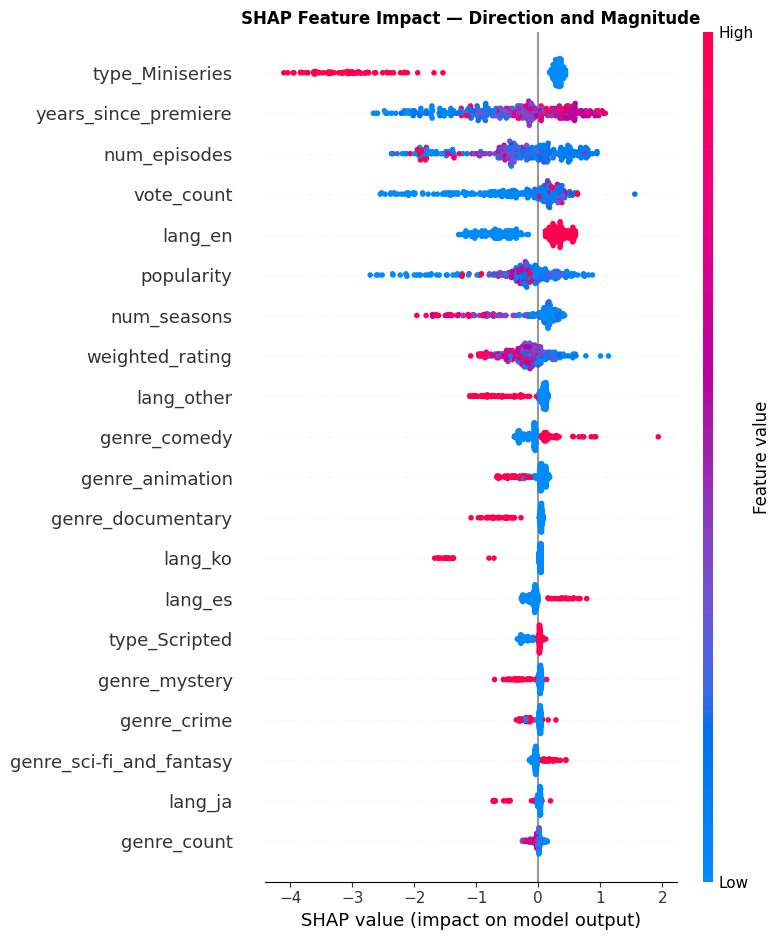

In [26]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Impact — Direction and Magnitude', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/10_shap_summary_dot.png', dpi=300, bbox_inches='tight')
plt.show()

Show: The Crew
Actual status: Canceled
Predicted cancellation probability: 96.9%


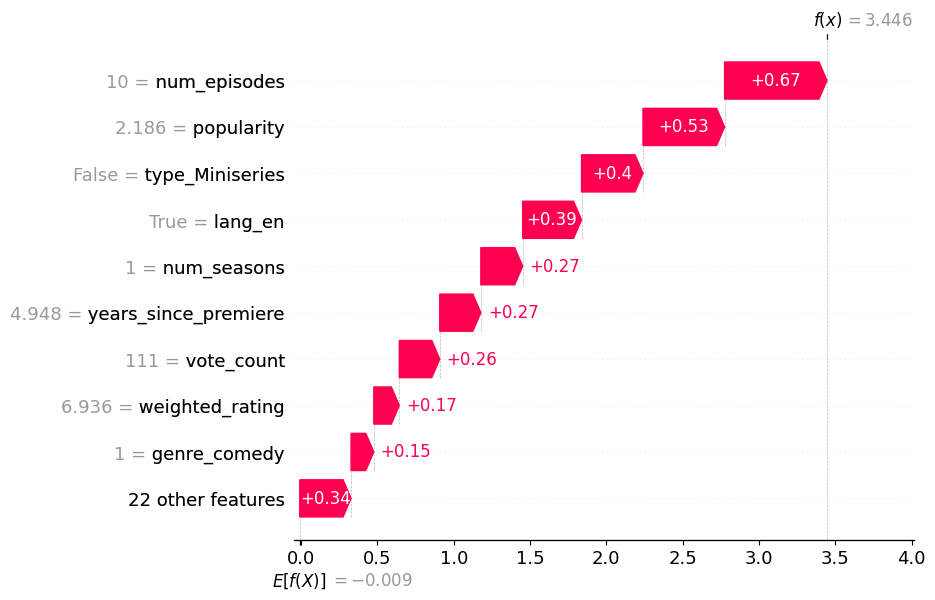

In [27]:
# Show the SHAP explanation for the highest-risk show in the test set
highest_risk_idx = y_prob_xgb.argmax()

print(f"Show: {df.iloc[X_test.index[highest_risk_idx]]['name']}")
print(f"Actual status: {df.iloc[X_test.index[highest_risk_idx]]['status']}")
print(f"Predicted cancellation probability: {y_prob_xgb[highest_risk_idx]:.1%}")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[highest_risk_idx],
        feature_names=X_test.columns.tolist()
    )
)


In [28]:
# Score every show in the full dataset
all_features = pd.concat([
    df[numeric_features + flag_features],
    pd.get_dummies(df['language_encoded'], prefix='lang'),
    pd.get_dummies(df['type'], prefix='type'),
    df[genre_features]
], axis=1)

In [29]:
# Align columns to match training and fill any missing dummies with 0
all_features = all_features.reindex(columns=X_train.columns, fill_value=0)

In [30]:
# Set cancellation risk score for every show
df['risk_score'] = champion.predict_proba(all_features)[:, 1]

In [31]:
# Normalize engagement proxy
df['engagement_score'] = (
    (df['vote_count'] - df['vote_count'].min()) / (df['vote_count'].max() - df['vote_count'].min()) +
    (df['popularity'] - df['popularity'].min()) / (df['popularity'].max() - df['popularity'].min()) +
    (df['num_seasons'] - df['num_seasons'].min()) / (df['num_seasons'].max() - df['num_seasons'].min())
) / 3

In [32]:
print(f"Risk score range:       {df['risk_score'].min():.3f} — {df['risk_score'].max():.3f}")
print(f"Engagement score range: {df['engagement_score'].min():.3f} — {df['engagement_score'].max():.3f}")
print(f"\nShows scored: {len(df)}")

Risk score range:       0.000 — 0.978
Engagement score range: 0.000 — 0.691

Shows scored: 1485


In [33]:
print("RISK SCORE DISTRIBUTION")
print(pd.cut(df['risk_score'], bins=[0, 0.3, 0.6, 1.0],
             labels=['Low', 'Medium', 'High']).value_counts().sort_index())

RISK SCORE DISTRIBUTION
risk_score
Low       1101
Medium     126
High       258
Name: count, dtype: int64


In [34]:
print("\nENGAGEMENT SCORE DISTRIBUTION")
print(df['engagement_score'].describe())
print(f"\nMedian engagement: {df['engagement_score'].median():.3f}")
print(f"Shows above 0.15:  {(df['engagement_score'] > 0.15).sum()}")
print(f"Shows above 0.20:  {(df['engagement_score'] > 0.20).sum()}")
print(f"Shows above 0.30:  {(df['engagement_score'] > 0.30).sum()}")
print(f"Shows above 0.50:  {(df['engagement_score'] > 0.50).sum()}")


ENGAGEMENT SCORE DISTRIBUTION
count    1485.000000
mean        0.015088
std         0.034421
min         0.000199
25%         0.002057
50%         0.006691
75%         0.015193
max         0.690909
Name: engagement_score, dtype: float64

Median engagement: 0.007
Shows above 0.15:  17
Shows above 0.20:  9
Shows above 0.30:  5
Shows above 0.50:  1


### Content Portfolio Segmentation
Two independent signals drive each show's portfolio action:
- **Risk tier**: XGBoost cancellation probability (Low < 0.35 / Medium 0.35–0.65 / High > 0.65)
- **Engagement tier**: percentile-based split at the median (top half = High, bottom half = Low)

Percentile thresholds are used for engagement because the score is heavily right-skewed (median = 0.007). A fixed numeric cutoff would classify 95%+ of shows as low-engagement and make the high-engagement segments nearly empty.

In [35]:
# Risk tier: fixed model-probability cutoffs
def risk_tier(score):
    if score < 0.35: # unlikely to be canceled
        return 'Low'
    elif score < 0.65:
        return 'Medium'
    else:
        return 'High' # highly likely to be canceled

In [36]:
# Engagement tier: percentile-based median split
engagement_median = df['engagement_score'].median()
def engagement_tier(score):
# scores each show in the top or bottom half based on engagement
    return 'High' if score >= engagement_median else 'Low'

In [37]:
df['risk_tier'] = df['risk_score'].apply(risk_tier)
df['engagement_tier'] = df['engagement_score'].apply(engagement_tier)

In [38]:
print("RISK TIER DISTRIBUTION")
print(df['risk_tier'].value_counts().reindex(['Low', 'Medium', 'High']))
print()

RISK TIER DISTRIBUTION
risk_tier
Low       1137
Medium     102
High       246
Name: count, dtype: int64



In [39]:
print("ENGAGEMENT TIER DISTRIBUTION")
print(df['engagement_tier'].value_counts())

ENGAGEMENT TIER DISTRIBUTION
engagement_tier
High    743
Low     742
Name: count, dtype: int64


In [54]:
# Set up portfolio action plan
conditions = [
    (df['risk_tier'] == 'Low')    & (df['engagement_tier'] == 'High'),
    (df['risk_tier'] == 'Low')    & (df['engagement_tier'] == 'Low'),
    (df['risk_tier'] == 'Medium') & (df['engagement_tier'] == 'High'),
    (df['risk_tier'] == 'Medium') & (df['engagement_tier'] == 'Low'),
    (df['risk_tier'] == 'High')   & (df['engagement_tier'] == 'High'),
    (df['risk_tier'] == 'High')   & (df['engagement_tier'] == 'Low'),
]

actions = [
    'Green-Light',
    'Renew Cautiously',
    'Renew Aggressively',
    'Renew Cautiously',
    'Harvest-and-End',
    'Sunset',
]
df['action_plan'] = np.select(conditions, actions, default='Review')

In [55]:
print("ACTION PLAN DISTRIBUTION")
print(df.groupby('action_plan').size())

ACTION PLAN DISTRIBUTION
action_plan
Green-Light           529
Harvest-and-End       148
Renew Aggressively     66
Renew Cautiously      644
Sunset                 98
dtype: int64


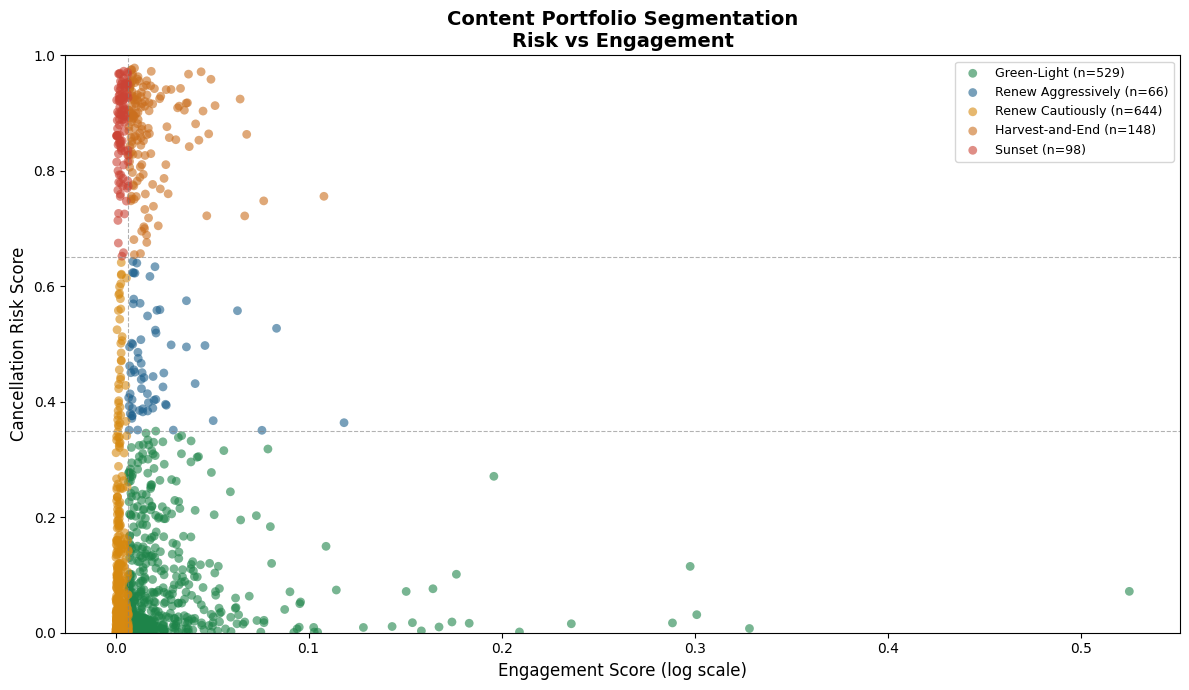

In [146]:
# color palette
ACTION_COLORS = {
    'Green-Light':        '#1e8449',
    'Renew Aggressively': '#1f618d',
    'Renew Cautiously':   '#d68910',
    'Harvest-and-End':    '#ca6f1e',
    'Sunset':             '#cb4335',
}

fig, ax = plt.subplots(figsize=(12, 7))

for action, color in ACTION_COLORS.items():
    subset = df[df['action_plan'] == action]
    ax.scatter(
        np.log1p(subset['engagement_score']),
        subset['risk_score'],
        c=color, label=f"{action} (n={len(subset)})",
        alpha=0.6, s=40, edgecolors='none'
    )

# Threshold lines
ax.axhline(0.35, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(0.65, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(np.log1p(df['engagement_score'].median()),
           color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_xlabel('Engagement Score (log scale)', fontsize=12)
ax.set_ylabel('Cancellation Risk Score', fontsize=12)
ax.set_title('Content Portfolio Segmentation\nRisk vs Engagement', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1)


plt.tight_layout()
plt.savefig('visualizations/11_portfolio_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


In [147]:
# Summary counts per segment
matrix_data = df.groupby(['risk_tier', 'engagement_tier']).agg(
    count=('action_plan', 'count'),
    action=('action_plan', 'first'),
    example=('name', lambda x: x.iloc[0])
).reset_index()

print(matrix_data)


  risk_tier engagement_tier  count              action              example
0      High            High    148     Harvest-and-End  Alice in Borderland
1      High             Low     98              Sunset       The Waterfront
2       Low            High    529         Green-Light      Stranger Things
3       Low             Low    608    Renew Cautiously          Star Search
4    Medium            High     66  Renew Aggressively               Arcane
5    Medium             Low     36    Renew Cautiously                  Bet


In [148]:
# Define the grid layout: (row, col) positions
# Rows: risk tier top-to-bottom = High → Medium → Low (most urgent at top)
# Cols: engagement left-to-right = Low → High

GRID_POSITIONS = {
    ('High',   'Low'):  (0, 0),
    ('High',   'High'): (0, 1),
    ('Medium', 'Low'):  (1, 0),
    ('Medium', 'High'): (1, 1),
    ('Low',    'Low'):  (2, 0),
    ('Low',    'High'): (2, 1),
}

# Build a lookup: (risk, engagement) → row data
segment_lookup = {
    (row['risk_tier'], row['engagement_tier']): row
    for _, row in matrix_data.iterrows()
}

# Preview: confirm each segment maps to the right cell
for (risk, eng), (r, c) in GRID_POSITIONS.items():
    seg = segment_lookup[(risk, eng)]
    print(f"[row {r}, col {c}]  {risk:6} risk / {eng:4} engagement  →  {seg['action']:22}  n={seg['count']}")


[row 0, col 0]  High   risk / Low  engagement  →  Sunset                  n=98
[row 0, col 1]  High   risk / High engagement  →  Harvest-and-End         n=148
[row 1, col 0]  Medium risk / Low  engagement  →  Renew Cautiously        n=36
[row 1, col 1]  Medium risk / High engagement  →  Renew Aggressively      n=66
[row 2, col 0]  Low    risk / Low  engagement  →  Renew Cautiously        n=608
[row 2, col 1]  Low    risk / High engagement  →  Green-Light             n=529


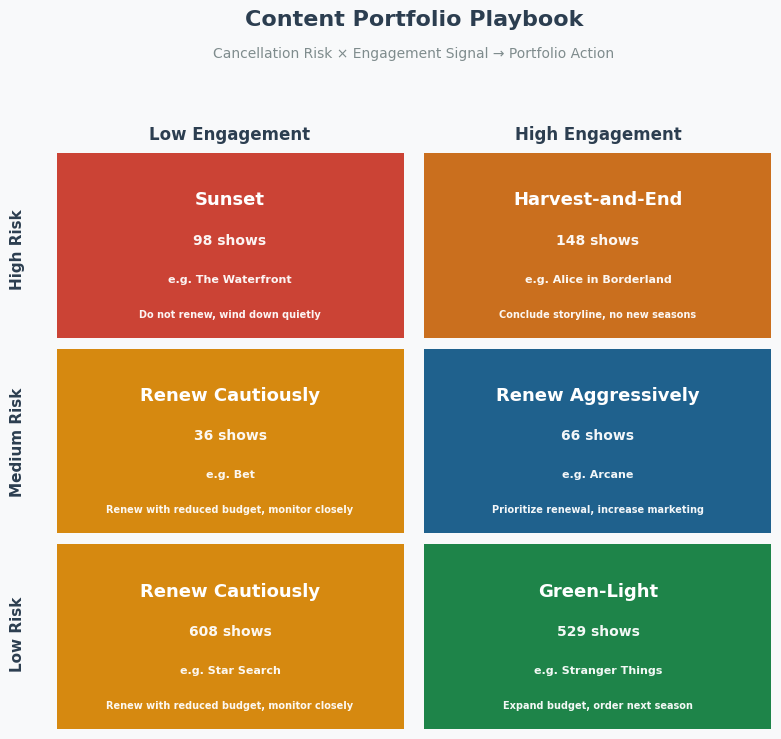

In [149]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8))
fig.patch.set_facecolor('#f8f9fa')

# Layout defined once — change these to adjust spacing
LAYOUT = dict(left=0.05, right=0.60, top=0.80, bottom=0.08, hspace=0.06, wspace=0.06)
plt.subplots_adjust(**LAYOUT)
grid_center = (LAYOUT['left'] + LAYOUT['right']) / 2

# Compute row label y-positions from layout so they always align
total_h = LAYOUT['top'] - LAYOUT['bottom']
row_h   = total_h / 3
row_centers = [
    LAYOUT['top'] - row_h * 0.5,   # High Risk row
    LAYOUT['top'] - row_h * 1.5,   # Medium Risk row
    LAYOUT['top'] - row_h * 2.5,   # Low Risk row
]

ACTION_DESCRIPTORS = {
    'Green-Light':        'Expand budget, order next season',
    'Renew Aggressively': 'Prioritize renewal, increase marketing',
    'Renew Cautiously':   'Renew with reduced budget, monitor closely',
    'Harvest-and-End':    'Conclude storyline, no new seasons',
    'Sunset':             'Do not renew, wind down quietly',
}


# Column headers
for c, label in enumerate(['Low Engagement', 'High Engagement']):
    axes[0, c].set_title(label, fontsize=12, fontweight='bold', color='#2c3e50', pad=10)

# Row headers — positions derived from layout, so always in whitespace
for label, y in zip(['High Risk', 'Medium Risk', 'Low Risk'], row_centers):
    fig.text(0.02, y, label, ha='center', va='center',
             fontsize=11, fontweight='bold', color='#2c3e50', rotation=90)

for (risk, eng), (r, c) in GRID_POSITIONS.items():
    ax = axes[r, c]
    seg = segment_lookup[(risk, eng)]
    color = ACTION_COLORS[seg['action']]

    ax.set_facecolor(color)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(0.5, 0.75, seg['action'],
            ha='center', va='center', transform=ax.transAxes,
            fontsize=13, fontweight='bold', color='white')
    ax.text(0.5, 0.53, f"{seg['count']} shows",
            ha='center', va='center', transform=ax.transAxes,
            fontsize=10, fontweight='bold', color='white', alpha=0.95)
    ax.text(0.5, 0.32, f"e.g. {seg['example']}",
            ha='center', va='center', transform=ax.transAxes,
            fontsize=8, fontweight='bold', color='white', alpha=0.95)
    ax.text(0.5, 0.13, ACTION_DESCRIPTORS[seg['action']],
        ha='center', va='center', transform=ax.transAxes,
        fontsize=7, fontweight='bold', color='white', alpha=0.95)


fig.suptitle('Content Portfolio Playbook', fontsize=16, fontweight='bold',
             color='#2c3e50', x=grid_center)
fig.text(grid_center, 0.92, 'Cancellation Risk × Engagement Signal → Portfolio Action',
         ha='center', fontsize=10, color='#7f8c8d')

plt.savefig('visualizations/12_portfolio_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
